# Generalized Linear Models (GLM)
*Data 200 · Applied Statistical Analysis · Instructor: Aayush Regmi*

---

Plain linear regression is wonderful when the outcome you're trying
to predict is a **real-valued, unbounded number** (sales, exam score,
house price). The moment your outcome looks different — *yes/no*,
*counts of events*, *waiting time* — the assumptions of OLS quietly
fall apart.

**Generalized Linear Models (GLMs)** are the principled fix. They
keep the familiar linear predictor $X\boldsymbol\beta$ but allow:

- the outcome $y$ to come from a **wider family of distributions**
  (not just Normal — also Binomial, Poisson, Gamma, Exponential, …),
- a **link function** to bridge the linear predictor and the outcome's
  natural scale.

By the end of this notebook you'll see that ordinary linear regression
is *one special case* of GLM, and you'll fit two more (**logistic**
and **Poisson**) on synthetic but believable data.


## Learning Objectives

By the end of this notebook you will be able to:

1. Explain the three components of a GLM — **random component**,
   **systematic component**, **link function** — and recognise that
   $y = mx + c$ is just GLM with a Normal random component and an
   identity link.
2. Compute probabilities for the **Binomial**, **Poisson**, and
   **Exponential** distributions both by formula and with `scipy.stats`.
3. State the general formula of the **exponential family** and identify
   its pieces.
4. Derive the **canonical link** for the Binomial ($\ln\frac{p}{1-p}$,
   the *logit*) and for the Poisson ($\ln\lambda$).
5. Explain the **sigmoid function** and how it serves as the inverse
   link for a Binomial GLM.
6. Fit and interpret a **logistic GLM** and a **Poisson GLM** in
   `statsmodels`, and visualise their fitted curves.


## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from math import comb, factorial

import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
rng = np.random.default_rng(0)


## 1. What GLM Solves

Plain linear regression assumes

$$y \;=\; \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \varepsilon,
\qquad \varepsilon \sim \mathcal{N}(0, \sigma^2).$$

It expects $y$ to be a **real, continuous, unbounded** number with
**Normally distributed errors**. That's a great fit for sales, exam
scores, or house prices, but it falls apart for outcomes like:

| Question | Outcome looks like… | OLS problem |
|---|---|---|
| Will this customer churn? | 0 / 1 (yes / no) | A line through 0/1 data goes below 0 and above 1 — meaningless probabilities. |
| How many calls will arrive in the next hour? | non-negative integer | A line can predict $-3$ calls. |
| How long until the next bus? | positive real number | Same — predictions can go negative. |

**GLM's pitch in one sentence:** keep the linear predictor
$X\boldsymbol\beta$ — but let $y$ come from a *suitable* distribution
and put a **link function** in between to keep the prediction on the
right scale.

Linear regression said $y = mx + c$. GLM says **$f(\mu) = mx + c$**
where $\mu$ is the mean of $y$ and $f$ is the link function. That's
the whole generalisation in a single line.


## 2. The Three Components of a GLM

Every GLM is built from three pieces.

1. **Random component — what kind of $y$ is it?**
   Pick a distribution from the **exponential family** that matches
   your outcome:
   - Continuous & unbounded → **Normal**
   - Binary or counts of successes → **Binomial**
   - Counts of events per interval → **Poisson**
   - Waiting times → **Exponential** (or Gamma)

2. **Systematic component — the linear predictor.**
   The same workhorse from OLS:
   $$\eta \;=\; X\boldsymbol\beta \;=\; \beta_0 + \beta_1 x_1 + \cdots.$$

3. **Link function $g(\cdot)$ — the bridge.**
   Connects the mean $\mu = \mathbb{E}[y]$ to the linear predictor
   $\eta$:
   $$g(\mu) \;=\; \eta \;=\; X\boldsymbol\beta.$$

And the punchline: **ordinary linear regression is GLM with a Normal
random component and the *identity* link** $g(\mu) = \mu$. Everything
we are about to do is just changing the first and third pieces.

| Outcome type | Distribution | Canonical link $g(\mu)$ |
|---|---|---|
| Continuous unbounded | Normal | identity: $\mu$ |
| Binary / proportion | Binomial | **logit**: $\ln\!\frac{p}{1-p}$ |
| Counts | Poisson | **log**: $\ln \lambda$ |
| Positive continuous | Gamma / Exponential | reciprocal or log |

We'll meet the second and third rows in detail.


## 3. Three Distributions GLMs Love — A Refresher

### 3.1 Binomial — counting successes in $n$ trials

If you flip a coin $n$ times and each flip is independently a
*success* with probability $p$, the number of successes $X$ follows a
**Binomial distribution**:

$$P(X = k) \;=\; \binom{n}{k} p^k (1-p)^{n-k},
\qquad k = 0, 1, \ldots, n.$$

### Coin-toss numerical example

A fair coin ($p = 0.5$) is flipped **10 times**. Let's compute three
probabilities, both by formula and with `scipy.stats.binom`.


In [ ]:
n, p = 10, 0.5

# (a) P(X = 5) — exactly five heads
p_eq_5    = comb(n, 5) * p**5 * (1 - p)**(n - 5)
p_eq_5_sp = stats.binom.pmf(5, n, p)
print(f"P(X = 5)   formula:  {p_eq_5:.4f}     scipy: {p_eq_5_sp:.4f}")

# (b) P(X >= 1) — at least one head = 1 - P(no heads at all)
p_ge_1    = 1 - p**0 * (1 - p)**n
p_ge_1_sp = 1 - stats.binom.cdf(0, n, p)
print(f"P(X >= 1)  formula:  {p_ge_1:.4f}     scipy: {p_ge_1_sp:.4f}")

# (c) P(X <= 1) — at most one head
p_le_1    = (1 - p)**n + n * p * (1 - p)**(n - 1)
p_le_1_sp = stats.binom.cdf(1, n, p)
print(f"P(X <= 1)  formula:  {p_le_1:.4f}     scipy: {p_le_1_sp:.4f}")


P(X = 5)   formula:  0.2461     scipy: 0.2461
P(X >= 1)  formula:  0.9990     scipy: 0.9990
P(X <= 1)  formula:  0.0107     scipy: 0.0107


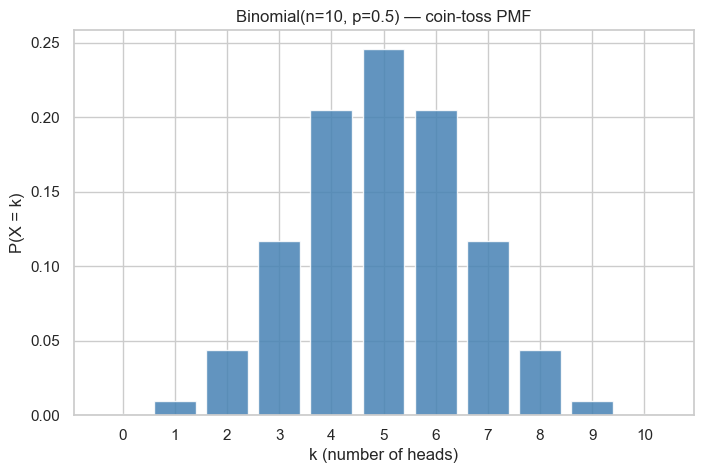

In [ ]:
ks = np.arange(0, n + 1)
plt.bar(ks, stats.binom.pmf(ks, n, p), color="steelblue", alpha=0.85)
plt.xlabel("k (number of heads)"); plt.ylabel("P(X = k)")
plt.title("Binomial(n=10, p=0.5) — coin-toss PMF")
plt.xticks(ks); plt.show()


### A second binomial example — the basketball free-throw shooter

A player makes 70% of their free throws ($p = 0.7$). They shoot
**8 free throws**. What's the probability they make **at least 6**?


In [ ]:
n_ft, p_ft = 8, 0.7

# By formula
p_ge_6_formula = sum(comb(n_ft, k) * p_ft**k * (1 - p_ft)**(n_ft - k)
                     for k in range(6, n_ft + 1))
p_ge_6_sp = 1 - stats.binom.cdf(5, n_ft, p_ft)

print(f"P(makes >= 6 of 8) formula: {p_ge_6_formula:.4f}")
print(f"P(makes >= 6 of 8) scipy:   {p_ge_6_sp:.4f}")


P(makes >= 6 of 8) formula: 0.5518
P(makes >= 6 of 8) scipy:   0.5518


### 3.2 Poisson — counting events per interval

Use Poisson when you're counting **how many events** occur in a fixed
interval of time (or space), at a roughly steady average rate
$\lambda$:

$$P(X = k) \;=\; \frac{\lambda^k e^{-\lambda}}{k!},
\qquad k = 0, 1, 2, \ldots$$

Both the **mean and variance** equal $\lambda$ — that's the Poisson's
signature.

### Example 1 — call center

A small call center receives an **average of 5 calls per hour**.


In [ ]:
lam = 5  # average calls per hour

# (a) P(X = 7) — exactly seven calls in an hour
p_7_formula = (lam**7 * np.exp(-lam)) / factorial(7)
p_7_sp      = stats.poisson.pmf(7, lam)
print(f"P(exactly 7 calls)   formula: {p_7_formula:.4f}     scipy: {p_7_sp:.4f}")

# (b) P(X >= 10) — overload — at least ten calls
p_ge_10 = 1 - stats.poisson.cdf(9, lam)
print(f"P(at least 10 calls):                                   {p_ge_10:.4f}")


P(exactly 7 calls)   formula: 0.1044     scipy: 0.1044
P(at least 10 calls):                                   0.0318


### Example 2 — traffic police outside Kings College Babarmahal

A traffic officer issues fines for wrongly parked bikes outside the
college gate. On a typical morning, fines arrive at the rate of **3
per hour**.

- What's the probability the officer issues **exactly 5 fines** in
  one hour?
- What's the probability of **at least 1 fine** in a 20-minute window?
  (For a 20-minute window the rate is $\lambda = 3 \times \frac{20}{60}
  = 1$.)


In [ ]:
lam_hour = 3       # fines per hour
p_5_hour = stats.poisson.pmf(5, lam_hour)
print(f"P(exactly 5 fines in 1 hour, lambda=3): {p_5_hour:.4f}")

lam_20min = 3 * 20 / 60   # rate scales with the interval — 1 fine / 20 min
p_ge_1_20min = 1 - stats.poisson.pmf(0, lam_20min)
print(f"P(at least 1 fine in 20 minutes, lambda=1): {p_ge_1_20min:.4f}")


P(exactly 5 fines in 1 hour, lambda=3): 0.1008
P(at least 1 fine in 20 minutes, lambda=1): 0.6321


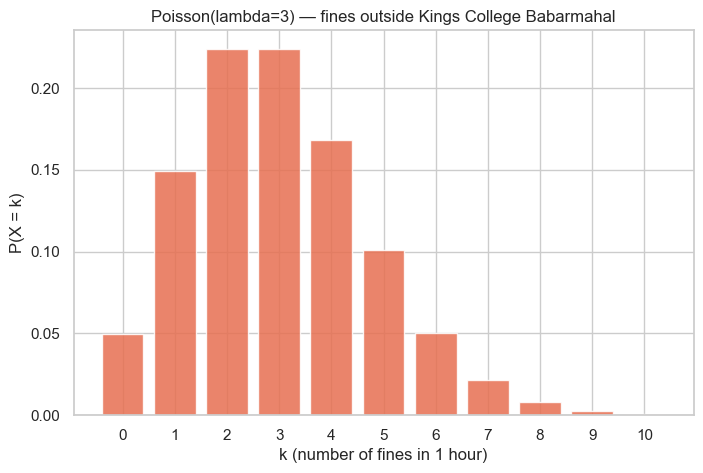

In [ ]:
ks = np.arange(0, 11)
plt.bar(ks, stats.poisson.pmf(ks, lam_hour), color="#e76f51", alpha=0.85)
plt.xlabel("k (number of fines in 1 hour)"); plt.ylabel("P(X = k)")
plt.title("Poisson(lambda=3) — fines outside Kings College Babarmahal")
plt.xticks(ks); plt.show()


### 3.3 Exponential — waiting time between events

If events arrive *Poisson-style* at rate $\lambda$, the **waiting
time** between two consecutive events follows an **Exponential
distribution**:

$$f(t) \;=\; \lambda e^{-\lambda t}, \qquad t \geq 0.$$

Mean wait $= 1/\lambda$.

**Example.** If fines arrive at $\lambda = 3$ per hour, the average
gap between two consecutive fines is $1/3$ hour = 20 min. What's the
probability of waiting **more than 30 minutes** (= 0.5 h)?


In [ ]:
lam = 3                          # rate per hour
wait = 0.5                       # 30 minutes in hours
p_wait = np.exp(-lam * wait)     # P(T > wait) = exp(-lambda * wait)
p_wait_sp = 1 - stats.expon.cdf(wait, scale=1 / lam)
print(f"P(wait > 30 min)  formula: {p_wait:.4f}     scipy: {p_wait_sp:.4f}")


P(wait > 30 min)  formula: 0.2231     scipy: 0.2231


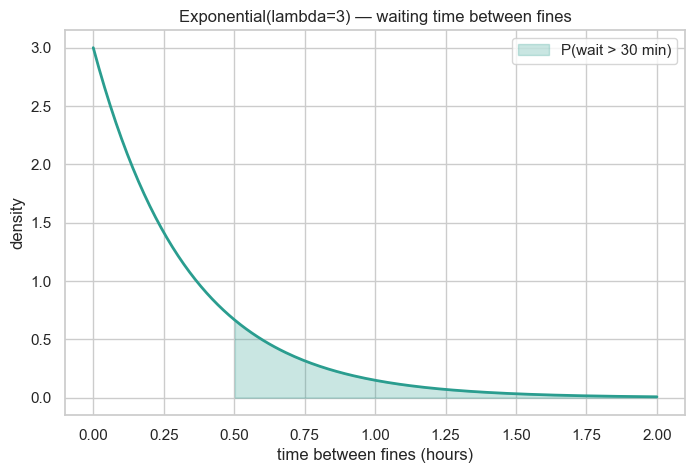

In [ ]:
ts = np.linspace(0, 2, 200)
plt.plot(ts, lam * np.exp(-lam * ts), color="#2a9d8f", lw=2)
plt.fill_between(ts[ts > wait], (lam * np.exp(-lam * ts))[ts > wait],
                 color="#2a9d8f", alpha=0.25, label="P(wait > 30 min)")
plt.xlabel("time between fines (hours)"); plt.ylabel("density")
plt.title("Exponential(lambda=3) — waiting time between fines")
plt.legend(); plt.show()


## 4. The Exponential Family — One Umbrella

All four distributions above (Normal, Binomial, Poisson, Exponential
/ Gamma) belong to a single mathematical family — the **exponential
family**. A distribution is in the exponential family if its density
or PMF can be written as

$$\boxed{\;
f(y; \theta, \phi) \;=\; \exp\!\left(
\frac{y\theta - b(\theta)}{a(\phi)} \;+\; c(y, \phi)
\right)\;}$$

Reading the pieces:

- **$\theta$** — the **natural (canonical) parameter**. The whole game
  is to express the distribution so that this $\theta$ pops out, because
  the **canonical link** is exactly the function that turns the mean
  $\mu$ into $\theta$.
- **$b(\theta)$** — the **cumulant function**. Its derivative
  $b'(\theta)$ equals the mean $\mu$.
- **$a(\phi)$** — a **scale (dispersion)** factor; for Binomial and
  Poisson it's just 1.
- **$c(y, \phi)$** — a normalising term that doesn't involve $\theta$.

| Distribution | $\theta$ (natural param) | Mean $\mu$ | Canonical link $g(\mu) = \theta$ |
|---|---|---|---|
| Normal       | $\mu$                   | $\mu$ | identity: $g(\mu) = \mu$ |
| Binomial     | $\ln\frac{p}{1-p}$      | $p$   | **logit**: $g(p) = \ln\frac{p}{1-p}$ |
| Poisson      | $\ln\lambda$            | $\lambda$ | **log**: $g(\lambda) = \ln\lambda$ |

We will now derive the middle and bottom rows.


## 5. Deriving the Canonical Link — Binomial

Take a single Bernoulli trial ($n = 1$). The PMF is

$$P(Y = y) \;=\; p^y (1-p)^{1-y}, \qquad y \in \{0, 1\}.$$

Re-write it inside an exponential by taking the log:

$$P(Y = y) \;=\; \exp\!\Big(y \ln p \;+\; (1 - y) \ln(1 - p)\Big).$$

Group the $y$ terms:

$$= \exp\!\Big(y \big[\ln p - \ln(1 - p)\big] \;+\; \ln(1 - p)\Big)
\;=\; \exp\!\Big(y \,\underbrace{\ln\!\tfrac{p}{1-p}}_{\theta}
\;+\; \underbrace{\ln(1-p)}_{-b(\theta)}\Big).$$

Compare with the exponential-family template — the natural parameter is

$$\boxed{\;\theta \;=\; \ln\!\frac{p}{1-p}.\;}$$

This quantity is called the **log-odds** or **logit** of $p$. The
canonical link for the Binomial is therefore

$$g(p) \;=\; \ln\!\frac{p}{1-p},$$

and a GLM with **Binomial random + logit link** is exactly **logistic
regression**. The model says

$$\ln\!\frac{p}{1-p} \;=\; \beta_0 + \beta_1 x_1 + \cdots.$$


## 6. Deriving the Canonical Link — Poisson

The Poisson PMF is

$$P(Y = y) \;=\; \frac{\lambda^y e^{-\lambda}}{y!}.$$

Take the log inside an exponential:

$$P(Y = y) \;=\; \exp\!\Big(y \ln \lambda \;-\; \lambda \;-\; \ln(y!)\Big).$$

Match against the template:

- $\theta \;=\; \ln \lambda$ (the natural parameter)
- $b(\theta) \;=\; \lambda \;=\; e^{\theta}$
- $c(y, \phi) \;=\; -\ln(y!)$

So

$$\boxed{\;\theta \;=\; \ln\lambda\;}$$

and the canonical link for the Poisson is the **log link**:

$$g(\lambda) \;=\; \ln \lambda.$$

A GLM with **Poisson random + log link** is **Poisson regression**:

$$\ln \lambda \;=\; \beta_0 + \beta_1 x_1 + \cdots
\quad\Longleftrightarrow\quad
\lambda \;=\; e^{\beta_0 + \beta_1 x_1 + \cdots}.$$

The exponential on the right is what guarantees $\lambda > 0$ no matter
what the linear predictor returns.


## 7. The Sigmoid Function

We just established that for a Binomial GLM

$$\eta \;=\; \ln\!\frac{p}{1-p}.$$

But we don't predict $\eta$ for users — we predict the **probability**
$p$. Solving the equation above for $p$ gives the **sigmoid** (also
called the **logistic function**):

$$\boxed{\;
p \;=\; \sigma(\eta) \;=\; \frac{1}{1 + e^{-\eta}}.
\;}$$

The sigmoid is the **inverse link** for the Binomial GLM. Its job is
to **squash** any real number $\eta \in (-\infty, \infty)$ into the
interval $(0, 1)$ — exactly where probabilities live.


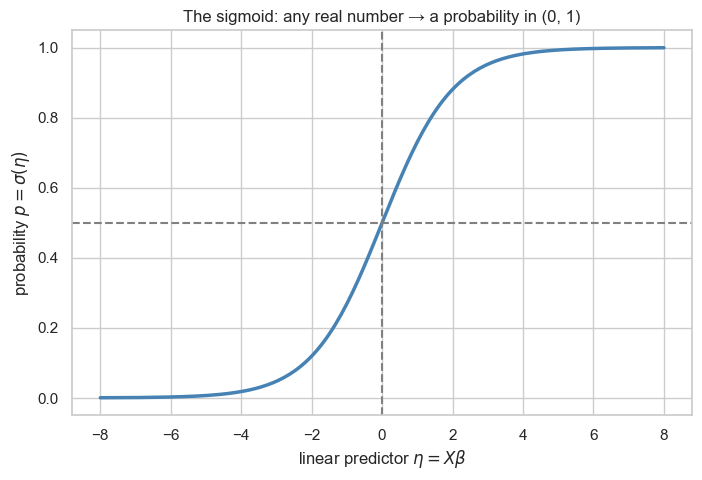

In [ ]:
z = np.linspace(-8, 8, 200)
sig = 1 / (1 + np.exp(-z))
plt.plot(z, sig, color="steelblue", lw=2.5)
plt.axhline(0.5, color="gray", ls="--")
plt.axvline(0,   color="gray", ls="--")
plt.xlabel(r"linear predictor $\eta = X\beta$")
plt.ylabel(r"probability $p = \sigma(\eta)$")
plt.title("The sigmoid: any real number → a probability in (0, 1)")
plt.show()


Three properties to remember:

1. $\sigma(0) = 0.5$ — the natural decision threshold.
2. $\sigma(\eta) \to 0$ as $\eta \to -\infty$, $\sigma(\eta) \to 1$
   as $\eta \to +\infty$.
3. The S-shape is **smooth and differentiable** — which is why
   gradient descent (see the Parameter Estimation notebook) can train
   models that use it.

**Putting it together** for the Binomial GLM:

$$\underbrace{X\boldsymbol\beta}_{\text{linear predictor }\eta}
\;\;\xrightarrow{\;\sigma(\cdot)\;}\;\;
\underbrace{p}_{\text{predicted probability}}
\;\;\xrightarrow{\;\text{Bernoulli draw}\;}\;\;
\underbrace{y \in \{0, 1\}}_{\text{observed outcome}}.$$


## 8. GLM in Action — Logistic Regression on a Delivery App

**Scenario.** A food-delivery app wants to predict whether a delivery
earns a **5-star rating** (yes / no) based on **delivery time in
minutes**. Faster deliveries should get more 5-star ratings.

We synthesise 200 deliveries where the *true* probability of a 5-star
rating is

$$p(\text{5\textbackslash star}) \;=\; \sigma(4 - 0.10 \cdot \text{delivery\_time}).$$


In [ ]:
n = 200
delivery_time = rng.uniform(10, 60, size=n)              # minutes
true_eta      = 4 - 0.10 * delivery_time                 # log-odds
true_p        = 1 / (1 + np.exp(-true_eta))
five_star     = rng.binomial(n=1, p=true_p)              # observed 0/1

deliveries = pd.DataFrame({
    "delivery_time": delivery_time,
    "five_star":     five_star,
})
deliveries.head()


,delivery_time,five_star
0,41.848084,0
1,23.489336,1
2,12.048676,1
3,10.826382,1
4,50.663512,0


### Fit the logistic GLM

In [ ]:
X = sm.add_constant(deliveries["delivery_time"])      # adds the intercept column
y = deliveries["five_star"]

logit_glm = sm.GLM(y, X, family=sm.families.Binomial()).fit()
print(logit_glm.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:              five_star   No. Observations:                  200
Model:                            GLM   Df Residuals:                      198
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -98.782
Date:                Sun, 03 May 2026   Deviance:                       197.56
Time:                        15:19:06   Pearson chi2:                     195.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3243
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             4.1342      0.599      6.903

### Reading the coefficients

- The intercept $\hat\beta_0$ is the log-odds of a 5★ rating when
  delivery time is 0 (a useful reference, not a real prediction).
- $\hat\beta_1$ for `delivery_time` is the change in **log-odds** per
  extra minute. Negative means slower deliveries are *less* likely to
  earn 5★.
- Exponentiating gives the **odds ratio** — "each extra minute
  multiplies the odds of 5★ by $e^{\hat\beta_1}$."


In [ ]:
b0, b1 = logit_glm.params
print(f"Coefficient on delivery_time:   {b1:.4f}  (log-odds per minute)")
print(f"Odds ratio per extra minute:    {np.exp(b1):.4f}")
print(f"=> each extra minute multiplies the odds of 5★ by ≈ {np.exp(b1):.3f}")


Coefficient on delivery_time:   -0.1041  (log-odds per minute)
Odds ratio per extra minute:    0.9012
=> each extra minute multiplies the odds of 5★ by ≈ 0.901


### Visualise — sigmoid fit vs. the data (and why OLS fails)

/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


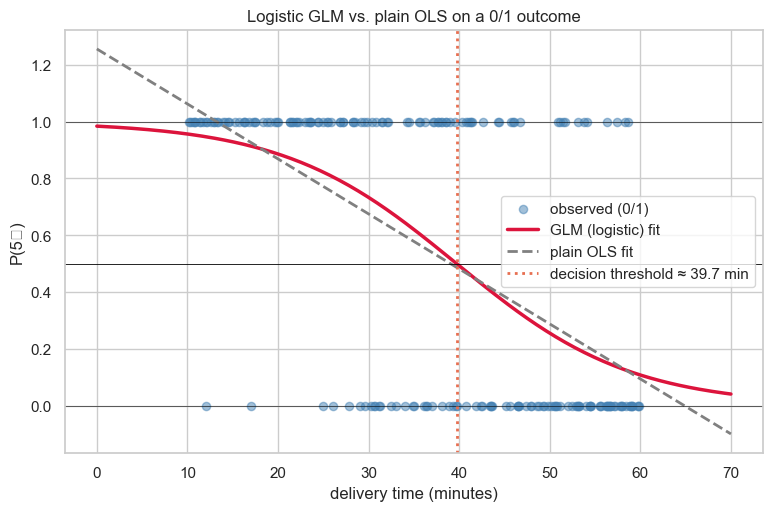

In [ ]:
x_grid = np.linspace(0, 70, 200)
X_grid = sm.add_constant(x_grid)
p_pred = logit_glm.predict(X_grid)

# A naive OLS line through the same 0/1 outcomes — to show why we *need* GLM
ols_line = sm.OLS(y, X).fit()
p_ols    = ols_line.predict(X_grid)

plt.figure(figsize=(9, 5.5))
plt.scatter(deliveries["delivery_time"], deliveries["five_star"],
            color="steelblue", alpha=0.5, s=35, label="observed (0/1)")
plt.plot(x_grid, p_pred,  color="crimson", lw=2.5, label="GLM (logistic) fit")
plt.plot(x_grid, p_ols,   color="gray",    lw=2,   ls="--", label="plain OLS fit")
plt.axhline(0.5, color="black", lw=0.6)
plt.axhline(0,   color="black", lw=0.4)
plt.axhline(1,   color="black", lw=0.4)

# Decision threshold: where the GLM curve crosses 0.5 → eta = 0 → x = -b0/b1
x_thresh = -b0 / b1
plt.axvline(x_thresh, color="#e76f51", ls=":", lw=2,
            label=f"decision threshold ≈ {x_thresh:.1f} min")

plt.xlabel("delivery time (minutes)")
plt.ylabel("P(5★)")
plt.title("Logistic GLM vs. plain OLS on a 0/1 outcome")
plt.legend(loc="center right"); plt.show()


Two things to notice:

1. The **dashed grey OLS line** wanders **below 0** for fast
   deliveries and **above 1** for slow ones — those are not valid
   probabilities. This is the failure mode that motivated GLM in §1.
2. The **red logistic curve** is the sigmoid we derived in §7,
   evaluated at the fitted $(\hat\beta_0, \hat\beta_1)$. It always
   stays in $(0, 1)$ and crosses the 0.5 threshold at
   $x = -\hat\beta_0 / \hat\beta_1$ — a meaningful **cut-off** the
   business can act on.


## 9. GLM in Action — Poisson Regression on Bike-Fine Tickets

Back to the traffic officer outside Kings College Babarmahal. The
fine-issuing rate is **not constant through the day** — it spikes
during morning and evening rush hours. We'll model:

$$\ln \lambda(\text{hour}) \;=\; \beta_0 + \beta_1 \cdot \text{hour}
\;+\; \beta_2 \cdot \text{hour}^2.$$

(A quadratic gives the curve a peak somewhere in the middle of the
day — exactly the rush-hour pattern.)


In [ ]:
n_hours = 200
hour       = rng.uniform(6, 20, size=n_hours)            # 6 AM to 8 PM
true_log_lam = -2.5 + 0.9 * hour - 0.035 * hour**2       # peaks around midday
true_lam   = np.exp(true_log_lam)
tickets    = rng.poisson(lam=true_lam)                   # observed counts

fines = pd.DataFrame({"hour": hour, "tickets": tickets})
fines.head()


,hour,tickets
0,8.830353,17
1,19.130672,4
2,7.326873,8
3,6.068592,4
4,10.520891,24


In [ ]:
X = sm.add_constant(np.column_stack([fines["hour"], fines["hour"] ** 2]))
X = pd.DataFrame(X, columns=["const", "hour", "hour_sq"])
y = fines["tickets"]

poisson_glm = sm.GLM(y, X, family=sm.families.Poisson()).fit()
print(poisson_glm.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                tickets   No. Observations:                  200
Model:                            GLM   Df Residuals:                      197
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -543.88
Date:                Sun, 03 May 2026   Deviance:                       168.49
Time:                        15:19:06   Pearson chi2:                     167.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.9713
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.9648      0.269    -11.028      0.0

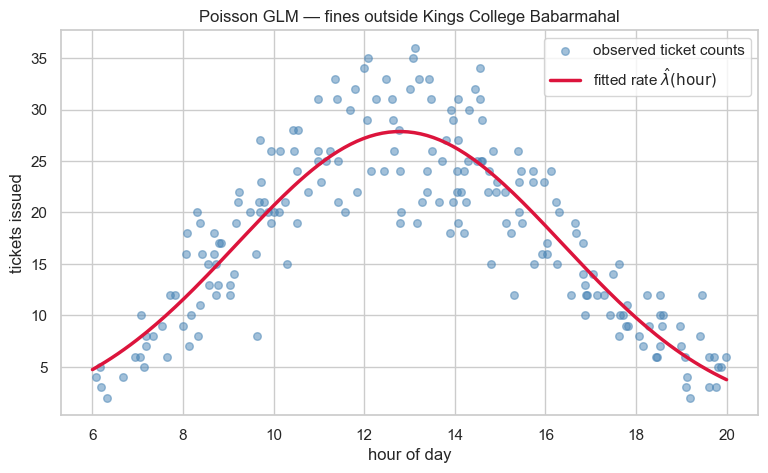

In [ ]:
# Visualise: scatter of observed counts + fitted rate curve lambda(hour)
x_grid = np.linspace(6, 20, 200)
X_grid = pd.DataFrame({"const": 1.0, "hour": x_grid, "hour_sq": x_grid ** 2})
lam_pred = poisson_glm.predict(X_grid)

plt.figure(figsize=(9, 5))
plt.scatter(fines["hour"], fines["tickets"], color="steelblue", alpha=0.5,
            s=30, label="observed ticket counts")
plt.plot(x_grid, lam_pred, color="crimson", lw=2.5,
         label=r"fitted rate $\hat\lambda(\mathrm{hour})$")
plt.xlabel("hour of day")
plt.ylabel("tickets issued")
plt.title("Poisson GLM — fines outside Kings College Babarmahal")
plt.legend(); plt.show()


The fitted curve never goes negative — guaranteed by the
$\lambda = e^{X\boldsymbol\beta}$ form — and its peak corresponds to
the busiest hour for fines. A plain linear regression here would
happily predict $-2$ tickets in the early morning, which is nonsense.

**Interpreting Poisson GLM coefficients.** Because of the log link,
$\hat\beta_j$ is the change in **log-rate** per unit increase of
$x_j$. Exponentiating gives a **rate multiplier**: $e^{\hat\beta_j}$
is the factor by which the expected count is multiplied when $x_j$
increases by one.


## 10. Key Takeaways

1. **GLM = pick a distribution + pick a link function.** The linear
   predictor $X\boldsymbol\beta$ stays the same; only the random
   component and the link change.
2. Plain linear regression is the **identity-link Normal GLM** —
   one row of a much larger table.
3. **Binomial outcomes** (0/1, proportions) get the **logit link**.
   The natural parameter is the log-odds $\ln\frac{p}{1-p}$. The
   inverse link is the **sigmoid**, which keeps predictions inside
   $(0, 1)$.
4. **Count outcomes** get the **log link**: $\ln \lambda = X\beta$.
   The inverse link is the **exponential**, which keeps the rate
   positive.
5. **All of these** sit inside the **exponential family**
   $f(y) = \exp\!\big(\frac{y\theta - b(\theta)}{a(\phi)} + c(y,\phi)\big)$.
   The **canonical link** is the function that maps the mean to the
   natural parameter $\theta$.
6. In `statsmodels` it's a one-liner — `sm.GLM(y, X, family=...)` —
   and the same coefficient-reading habits transfer, except you
   interpret $\hat\beta_j$ on the **link scale** (log-odds for
   logistic, log-rate for Poisson) and exponentiate for an intuitive
   factor.


## 11. Practice Exercises

1. **Coin probabilities by hand.** A biased coin lands heads with
   $p = 0.3$. It is flipped 12 times. Compute (a) $P(X = 4)$,
   (b) $P(X \geq 6)$, (c) $P(X \leq 2)$. First by formula, then check
   each one with `scipy.stats.binom`.
2. **Logistic GLM on a new dataset.** Generate 300 students whose
   probability of passing an exam is
   $\sigma(-3 + 0.6 \cdot \text{hours\_studied})$. Fit a logistic GLM
   and report the hours-studied threshold above which $P(\text{pass})
   > 0.5$.
3. **Poisson GLM on monthly bug reports.** Suppose a software team
   averages $\lambda = e^{0.5 + 0.05 \cdot \text{users}}$ bug reports
   per week, where `users` is in thousands of active users (range
   1–30). Simulate 150 weeks of data, fit a Poisson GLM, and verify
   the recovered $\hat\beta$ are close to the true values.
